In [1]:
import numpy as np
from collections import defaultdict

class NSRCountriesTopology:
    """
    针对 Countries 数据集大幅简化的特制版 NSR 模型。
    关闭了动态置信度、支持度与复杂推理阈值设置，只通过基础认知拓扑映射和传导进行层级与邻国推理。
    """
    def __init__(self, num_entities, num_relations, r_locatedIn, r_neighborOf):
        self.N = num_entities
        self.M = num_relations
        self.r_loc = r_locatedIn
        self.r_nei = r_neighborOf
        
        # W_beta_beta 存储三元组物理神经连接：形状为 (N*M, N*M)
        self.W_beta_beta = np.zeros((self.N * self.M, self.N * self.M))
        
        # 这里仍保留了 W_beta_gamma (用于代表激活存在与关联，虽然在极简推理中W_beta_beta足够完成传导)
        self.W_beta_gamma = np.zeros((self.N, self.M))

        # 统计调试
        self.stat_total_queries = 0

    def _vec_index(self, e, r): 
        return r * self.N + e

    def fit(self, train_triples):
        """
        学习阶段：只需要学基础的 W_{beta,gamma}, W_{alpha,beta}, W_{beta,beta}
        以及基于 neighborOf 的对称连接补充。
        """
        self.train_triples = list(train_triples)
        
        for h, r, t in train_triples:
            idx_h = self._vec_index(h, r)
            idx_t = self._vec_index(t, r)
            
            # W_beta_beta: \beta^{r}_{h} -> \beta^{r}_{t}
            self.W_beta_beta[idx_t, idx_h] = 1.0
            
            # 记录在 beta -> gamma 映射活跃存在
            self.W_beta_gamma[h, r] = 1.0
            self.W_beta_gamma[t, r] = 1.0
            
            # 对称关系处理 (neighborOf)：学习 W^1_{gamma delta, delta gamma}，实质上等于补充镜像的神经连接
            if r == self.r_nei:
                self.W_beta_beta[idx_h, idx_t] = 1.0
                
        return self

    def _activate_beta_project_alpha(self, active_entities, r):
        """
        基础的神经激活与投射步骤：
        给定 alpha 层的活跃节点集合 active_entities，和 gamma 层的关系 r：
        1. 激活 beta 层中的对应神经元 beta^{r}_{e}
        2. 基于 W_beta_beta 激发相连神经元 beta^{r}_{t}
        3. 投射回 alpha 层，获得目标实体集合
        """
        next_entities = set()
        for e in active_entities:
            idx_e = self._vec_index(e, r)
            
            # 拿到被激发的目标beta分布
            col = self.W_beta_beta[:, idx_e]
            activated_indices = np.where(col > 0)[0]
            
            for a_idx in activated_indices:
                # 确定是由同关系 r 的 beta 投射过去的
                if a_idx // self.N == r:
                    t = a_idx % self.N
                    next_entities.add(t)
                    
        return next_entities

    def _climbing_located_in(self, start_entity):
        """
        执行 S1 与后续 S3 的爬树逻辑：
        对于给定节点，通过 \\gamma 层的 r1(locatedIn) 激活 \\beta，
        循环利用 W_beta_beta 传递直到没有更高的上级节点，并返回此时的结果集。
        """
        current_set = {start_entity}
        while True:
            next_set = self._activate_beta_project_alpha(current_set, self.r_loc)
            if not next_set:
                # 如果 "再次重复，无结果"，则返回上一次的结果 (当前所属的顶层区/大区)
                return current_set
            current_set = next_set

    def infer(self, h_q, r_q):
        """
        前向推理过程，严格遵循业务需求中的 S1, S2, S3 规则组合计算最终得分。
        """
        self.stat_total_queries += 1
        final_scores = defaultdict(float)
        
        # 针对本次任务，非 locatedIn 的查询可以直接退化或快速结算
        if r_q != self.r_loc:
            ans = self._activate_beta_project_alpha({h_q}, r_q)
            return {e: 1.0 for e in ans}
            
        # --- S1: 内部传递性推理尝试 ---
        # 尝试直接进行 locatedIn 爬树动作 (例如 h_q 是个次级区域，它可以直通大区)
        s1_results = self._climbing_located_in(h_q)
        
        # 若 s1_results != {h_q} 意味着爬树成功 (有实际向上传导)
        if s1_results != {h_q}:
            for target in s1_results:
                final_scores[target] += 1.0
            return dict(final_scores)
            
        # --- S2 & S3: 邻国推理 / 3跳长路径推理 ---
        # 若经历了一层 S1 会发现无结果 (意味着 h_q 是没有直接 locatedIn 的国家本体)
        # "故使用 \\gamma 层的 r2(neighborOf) 和 \\alpha 层 c1 激活 \\beta 层..."
        neighbor_nodes = self._activate_beta_project_alpha({h_q}, self.r_nei)
        
        # 对于拿到的每一个邻接次级节点 c2:
        for n_c2 in neighbor_nodes:
            # "再通过 \\gamma 层的 r1 ... 激活 \\beta ... 再次重复直到无结果"
            root_nodes = self._climbing_located_in(n_c2)
            
            # "最后应该会得到多个结果，根据被激活次数得到答案" (对结果进行频次累加评分)
            for target in root_nodes:
                final_scores[target] += 1.0
                
        return dict(final_scores)

    def explain_inference(self, h_q, r_q, id_to_entity, id_to_relation):
        """直观地输出模型激活与爬树日志"""
        print(f"\\n[Explain] 推理意图: ({id_to_entity[h_q]} -- {id_to_relation[r_q]} --> ?)")
        final_scores = self.infer(h_q, r_q)
        
        if not final_scores:
            print("  未能通过 S1-S3 建立有效激活传导。")
        else:
            sorted_ans = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
            print("  最终激活分布与打分 (按照神经元兴奋汇聚次数排序):")
            for i, (e, s) in enumerate(sorted_ans[:5]):
                print(f"    {i+1}. [{id_to_entity[e]}] (激活次频: {s:.1f})")


In [6]:
from pykeen.datasets import Countries
from pykeen.datasets.base import UnpackedRemoteDataset
from collections import defaultdict
from tqdm.auto import tqdm
import numpy as np

# 构建 S2 和 S3 难度的数据集加载器
class Countries_S2(UnpackedRemoteDataset):
    def __init__(self, **kwargs):
        super().__init__(
            training_url="https://raw.githubusercontent.com/ZhenfengLei/KGDatasets/master/Countries/Countries_S2/train.txt",
            testing_url="https://raw.githubusercontent.com/ZhenfengLei/KGDatasets/master/Countries/Countries_S2/test.txt",
            validation_url="https://raw.githubusercontent.com/ZhenfengLei/KGDatasets/master/Countries/Countries_S2/valid.txt",
            **kwargs,
        )

class Countries_S3(UnpackedRemoteDataset):
    def __init__(self, **kwargs):
        super().__init__(
            training_url="https://raw.githubusercontent.com/ZhenfengLei/KGDatasets/master/Countries/Countries_S3/train.txt",
            testing_url="https://raw.githubusercontent.com/ZhenfengLei/KGDatasets/master/Countries/Countries_S3/test.txt",
            validation_url="https://raw.githubusercontent.com/ZhenfengLei/KGDatasets/master/Countries/Countries_S3/valid.txt",
            **kwargs,
        )

# --- 极简版 Filtered 评估逻辑 ---
def evaluate_hits_1(model, test_triples_factory, all_true_triples):
    test_triples = test_triples_factory.mapped_triples.numpy()
    true_tails = defaultdict(set)
    for h, r, t in all_true_triples:
        true_tails[(h, r)].add(t)
        
    hits_1 = 0
    total = len(test_triples)
    for h, r, t_true in tqdm(test_triples, desc="Evaluating", leave=False):
        pred_scores = model.infer(h, r)
        candidates = [(e, pred_scores.get(e, 0.0)) for e in range(model.N)]
        candidates.sort(key=lambda x: x[1], reverse=True)
        
        filtered_rank = 1
        for e, score in candidates:
            if e == t_true: break
            if e in true_tails[(h, r)]: continue
            filtered_rank += 1
            
        if filtered_rank == 1:
            hits_1 += 1
            
    return hits_1 / total

# --- 统一的批量实验调用 ---
datasets_map = {
    "S1": Countries(),
    "S2": Countries_S2(),
    "S3": Countries_S3()
}

results = {}
global_models = {}   # 保存训练好的模型给后面可视化用
global_id_maps = {}  # 保存名称映射给可视化

for mode, dataset in datasets_map.items():
    print(f"\n[{mode}] 开始训练与评估...")
    train_tf = dataset.training
    num_ent, num_rel = train_tf.num_entities, train_tf.num_relations
    r_loc = train_tf.relation_to_id.get('locatedin')
    r_nei = train_tf.relation_to_id.get('neighbor')
    
    # 实例化并训练极简版 NSR
    model = NSRCountriesTopology(num_ent, num_rel, r_loc, r_nei)
    model.fit(train_tf.mapped_triples.numpy())
    
    # 合并所有的三元组作为 Filter 依据
    all_triples = np.concatenate([
        train_tf.mapped_triples.numpy(),
        dataset.validation.mapped_triples.numpy(),
        dataset.testing.mapped_triples.numpy()
    ], axis=0)
    
    hits1_score = evaluate_hits_1(model, dataset.testing, all_triples)
    results[mode] = hits1_score
    print(f"[{mode}] Test Hits@1: {hits1_score:.4f}")
    
    global_models[mode] = model
    global_id_maps[mode] = {v: k for k, v in train_tf.entity_to_id.items()}

print("\n=== 最终推导能力汇总 ===")
for mode, h1 in results.items():
    print(f" * {mode} Hits@1: {h1:.4f}")


[S1] 开始训练与评估...


[S1] Test Hits@1: 1.0000

[S2] 开始训练与评估...


[S2] Test Hits@1: 1.0000

[S3] 开始训练与评估...


[S3] Test Hits@1: 1.0000

=== 最终推导能力汇总 ===
 * S1 Hits@1: 1.0000
 * S2 Hits@1: 1.0000
 * S3 Hits@1: 1.0000


### S3 Visualization
下面是Test中的国家/地区：
> belgium(比利时), canada(加拿大), croatia(克罗地亚), guatemala(危地马拉), hong_kong(香港), israel(以色列), jordan(约旦), libya(利比亚), mali(马里), mauritania(毛里塔尼亚), monaco(摩纳哥), morocco(摩洛哥), paraguay(巴拉圭), poland(波兰), republic_of_the_congo(刚果共和国), russia(俄罗斯), san_marino(圣马力诺), saudi_arabia(沙特阿拉伯), sri_lanka(斯里兰卡), suriname(苏里南), syria(叙利亚), uganda(乌干达), yemen(也门), zambia(赞比亚)

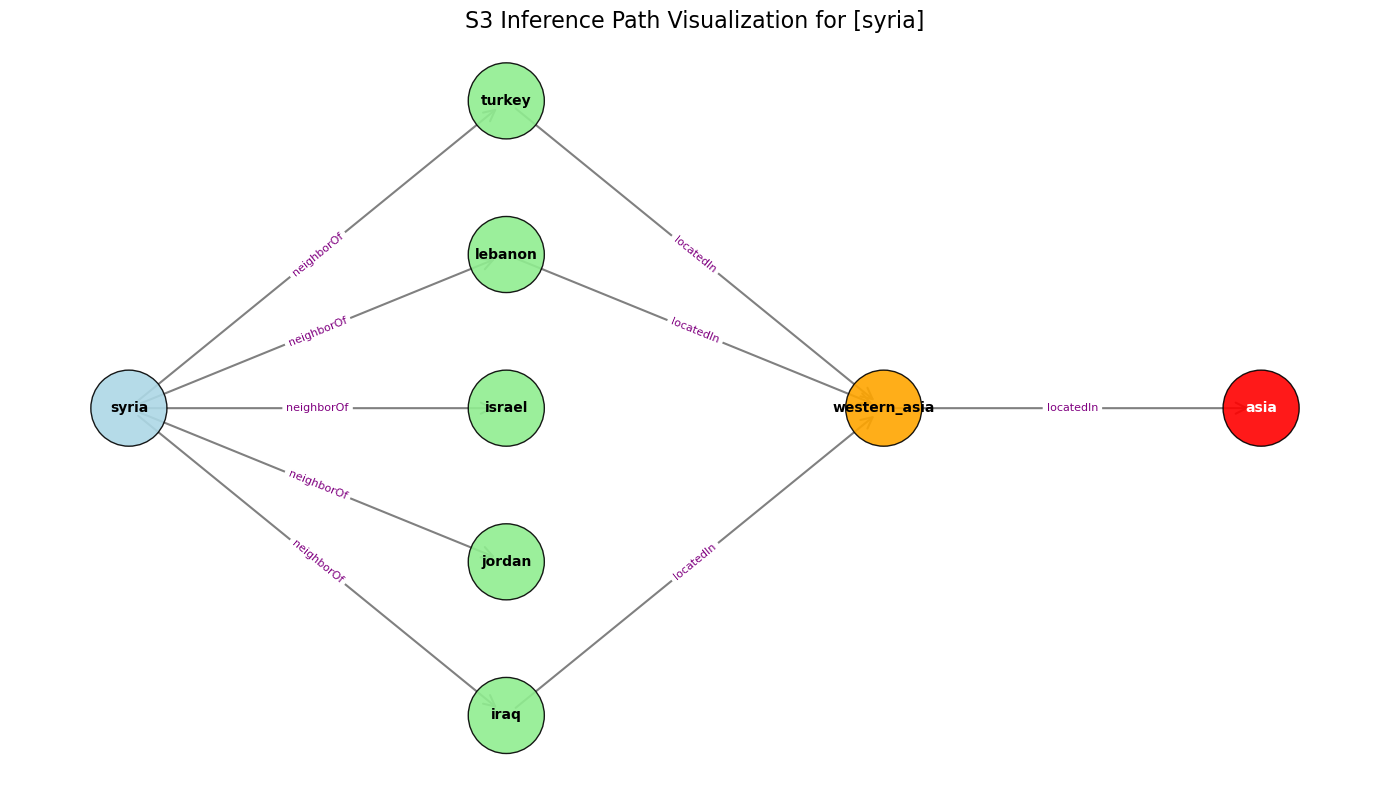

[syria] 通过推导到达的大区为: {'asia'}
[syria] 的标准答案(Ground Truth)大区为: {'asia'}


In [16]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def visualize_s3_inference_graph(model, id_to_entity, start_entity_name="belgium", all_true_triples=None):
    """
    额外可视化模块：针对特定的实体，绘制一幅 S3 任务中典型的
    "国家 -> 邻国 -> 次级区域 -> 大区域" 的推演拓扑路网。
    如果有传入所有的三元组信息，会将正确的Ground Truth大区答案标为红底白字。
    其他的推理落脚点大区则标为灰色，以作区分。
    """
    entity_to_id = {v: k for k, v in id_to_entity.items()}
    start_ent = entity_to_id.get(start_entity_name)
    
    if start_ent is None:
        print(f"实体 {start_entity_name} 不存在于该字典中")
        return
        
    G = nx.DiGraph()
    G.add_node(start_entity_name, layer=0, color="lightblue")
    
    # 获取该查询的 Ground Truth 选项
    ground_truth_entities = set()
    if all_true_triples is not None:
        for h, r, t in all_true_triples:
            if h == start_ent and r == model.r_loc:
                ground_truth_entities.add(t)
    
    # 1. 向外伸展找 neighbor 
    neighbors = model._activate_beta_project_alpha({start_ent}, model.r_nei)
    
    final_hit_regions = set()
    
    for n in neighbors:
        n_name = id_to_entity[n]
        G.add_node(n_name, layer=1, color="lightgreen")
        G.add_edge(start_entity_name, n_name, label="neighborOf")
        
        # 2. 从每个 neighbor 找所在的“次级区域” (1跳 locatedIn)
        subregions = model._activate_beta_project_alpha({n}, model.r_loc)
        for sub in subregions:
            sub_name = id_to_entity[sub]
            G.add_node(sub_name, layer=2, color="orange")
            G.add_edge(n_name, sub_name, label="locatedIn")
            
            # 3. 从“次级区域”爬升至“大区” (2跳 locatedIn)
            macroregions = model._activate_beta_project_alpha({sub}, model.r_loc)
            for macro in macroregions:
                # 达到最高的大区
                macro_name = id_to_entity[macro]
                
                # 判断当前大区是不是标准答案 (Ground Truth)
                is_gt = macro in ground_truth_entities
                node_color = "red" if is_gt else "lightgray"
                
                G.add_node(macro_name, layer=3, color=node_color)
                G.add_edge(sub_name, macro_name, label="locatedIn")
                final_hit_regions.add(macro_name)

    # ==== 开始绘图 ====
    plt.figure(figsize=(14, 8))
    
    # 根据自定义的 layer 属性来进行分层 (multipartite_layout) 
    # 可以得到左到右：起点 -> 邻国 -> 小区 -> 大区 的效果
    pos = nx.multipartite_layout(G, subset_key="layer")
    
    node_colors = [data["color"] for _, data in G.nodes(data=True)]
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, edgecolors="black", node_size=3000, alpha=0.9)
    nx.draw_networkx_edges(G, pos, arrowsize=20, arrowstyle="->", edge_color="gray", width=1.5)
    
    # 调整 Labels 的字体颜色，使得红色节点的文字为白色，便于阅读
    labels = {node: node for node in G.nodes()}
    for node, (x, y) in pos.items():
        color = "white" if G.nodes[node]["color"] == "red" else "black"
        plt.text(x, y, node, fontsize=10, fontweight="bold", color=color, 
                 ha='center', va='center')
    
    # 添加边属性（关系类型）
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='purple', font_size=8)

    plt.title(f"S3 Inference Path Visualization for [{start_entity_name}]", fontsize=16)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    
    gt_names = {id_to_entity[e] for e in ground_truth_entities}
    print(f"[{start_entity_name}] 通过推导到达的大区为: {final_hit_regions}")
    print(f"[{start_entity_name}] 的标准答案(Ground Truth)大区为: {gt_names}")


# 取出刚刚在 S3 数据集上已经 Train 好的模型及对应的全部数据
s3_model = global_models["S3"]
s3_id_map = global_id_maps["S3"]
s3_dataset = datasets_map["S3"]

# 只有合并 Training、Validation 和 Testing 中所有的三元组
# 才能保证我们画图时针对任意国家的 Ground Truth 答案能够被找到
s3_all_triples = np.concatenate([
    s3_dataset.training.mapped_triples.numpy(),
    s3_dataset.validation.mapped_triples.numpy(),
    s3_dataset.testing.mapped_triples.numpy()
], axis=0)

# 选用 jordan (或其他任意实体) 作为可视化示范节点
visualize_s3_inference_graph(
    model=s3_model, 
    id_to_entity=s3_id_map, 
    start_entity_name="syria", 
    all_true_triples=s3_all_triples
)